## Polynomial Regression
> multiple features

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.read_csv('calories.csv')
df.head()

,age,exercise_min,heart_rate,calories_burned
0,56,46.660231,131.951222,149.971814
1,46,53.649343,125.261020,148.528043
2,32,85.317185,122.061045,234.736706
3,60,40.888211,134.771227,130.136709
4,25,86.895245,102.419220,263.670132


In [3]:
df[['age', 'exercise_min', 'heart_rate', 'calories_burned']].corr()

,age,exercise_min,heart_rate,calories_burned
age,1.000000,0.029148,0.059479,0.316418
exercise_min,0.029148,1.000000,-0.030291,0.891306
heart_rate,0.059479,-0.030291,1.000000,-0.071215
calories_burned,0.316418,0.891306,-0.071215,1.000000


> We will keep heart rate as constant in 3d plot, as it is having least correlation

In [7]:
x = df.iloc[:, 0:3]
y = df.iloc[:, -1]

## Linear Regression

In [ ]:
# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

# model train
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

print('Intercept: ',lr.intercept_)
print('Coeffiecient: ',lr.coef_)
print('R2 Score: ',r2_score(y_test, y_pred_lr))

Intercept:  -47.83840206509959
Coeffiecient:  [ 1.63191991  2.78544747 -0.1728475 ]
R2 Score:  0.8761571184783593


> as expected, the coef corresposding to `heart_rate` is the least, hence we'll keep it constant.

In [30]:
# 3d plot: plane of regression
# meshgrids
x_range = np.linspace(df['age'].min(), df['age'].max(), 30)
y_range = np.linspace(df['exercise_min'].min(), df['exercise_min'].max(), 30)
xx,yy = np.meshgrid(x_range, y_range)

# keeping heart_rate constant
heart_rate_mean = df['heart_rate'].mean()
heart_rate_col = np.full(xx.ravel().shape, heart_rate_mean)


pred_input = np.c_[xx.ravel(), yy.ravel(), heart_rate_col]
zz = lr.predict(pred_input).reshape(xx.shape)

fig = px.scatter_3d(df, 
                  x = 'age',
                  y = 'exercise_min', 
                  z = 'calories_burned', 
                  color = 'calories_burned',
                  color_continuous_scale = 'magma')
fig.add_surface(x = x_range, y = y_range, z = zz, name = 'Plane of regression',opacity = 0.7)
fig.show()

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



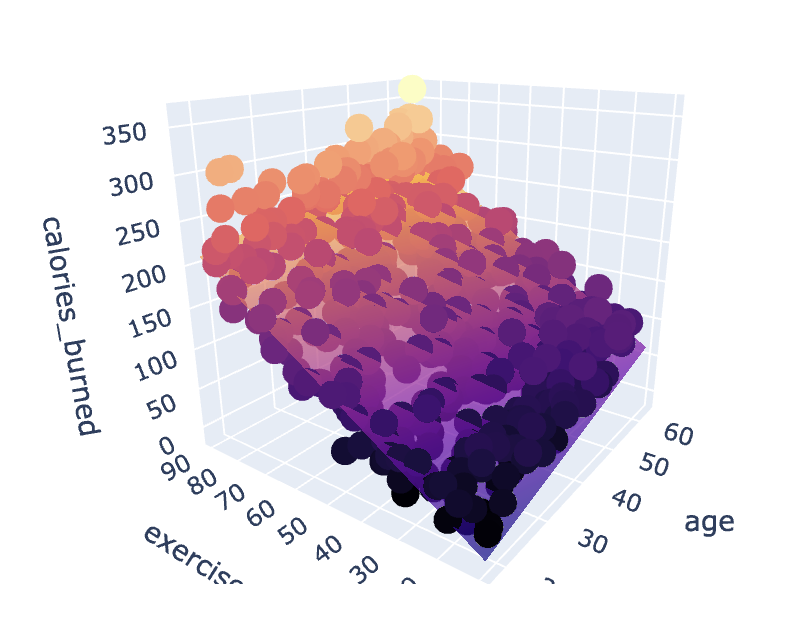
> image pasted as markdown

## 🔰 Polynomial Features

In [32]:
# polynomial features
poly = PolynomialFeatures(degree=2, include_bias=True)      # bias is x^0
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)


# model train
lr2 = LinearRegression()
lr2.fit(x_train_trans, y_train)
y_pred_poly = lr2.predict(x_test_trans)

print('Intercept: ',lr2.intercept_)
print('Coeffiecient: ',lr2.coef_)
print('R2 Score: ',r2_score(y_test, y_pred_poly))

Intercept:  -1.5832608933981476
Coeffiecient:  [ 0.00000000e+00 -1.57649833e-01  4.48820376e-01  1.75156758e-01
  2.02815032e-02 -5.11277287e-03  3.26258801e-03  3.96432080e-02
 -1.12575223e-02  2.97166158e-04]
R2 Score:  0.9580927425920986


In [49]:
# plot of curved plane of Regression

# meshgrids
x_range2 = np.linspace(df['age'].min(), df['age'].max(), 30)
y_range2 = np.linspace(df['exercise_min'].min(), df['exercise_min'].max(), 30)
xx2,yy2= np.meshgrid(x_range2, y_range2)

heart_rate_const = df['heart_rate'].mean()
heart_rate_col2 = np.full(xx2.ravel().shape, heart_rate_const)

pred_input2 = np.c_[xx2.ravel(), yy2.ravel(), heart_rate_col2]      # this works as x_test in predict() method
                                                                    # hence 'poly.transform()' ing it.
pred_input2_poly = poly.transform(pred_input2)
zz2 = lr2.predict(pred_input2_poly).reshape(xx2.shape)

fig2 = px.scatter_3d(df, 
                  x = 'age',
                  y = 'exercise_min', 
                  z = 'calories_burned', 
                  color = 'calories_burned',
                  color_continuous_scale = 'viridis',
                  opacity=0.7)
fig2.add_surface(x = x_range2, y = y_range2, z = zz2, name = 'Curved Plane of regression')
fig2.show()

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



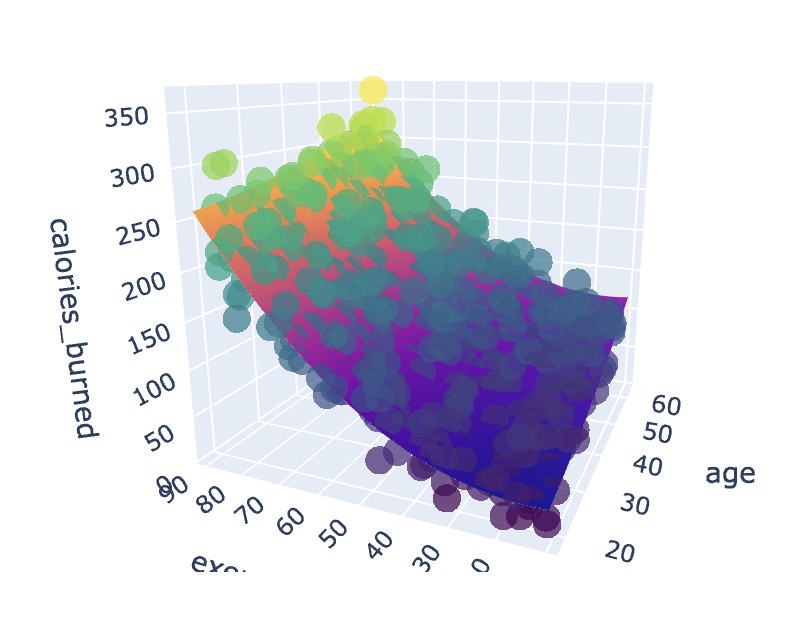
>image pasted as markdown

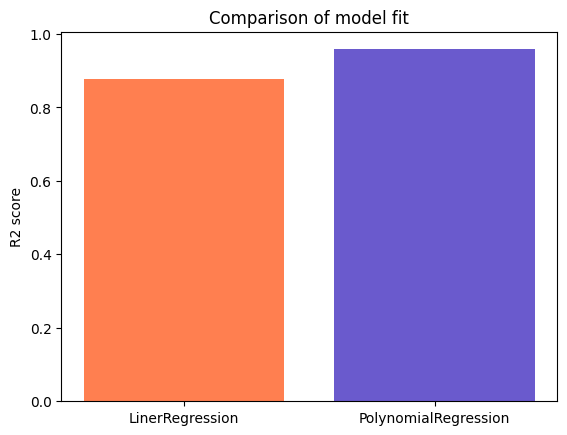

In [35]:
# comparison of r2 scores
import matplotlib.pyplot as plt

data = {
    'LinerRegression': r2_score(y_test, y_pred_lr),
    'PolynomialRegression':r2_score(y_test, y_pred_poly)
}
plt.bar(data.keys(), data.values(), color = ['coral', 'slateblue'])
plt.ylabel('R2 score')
plt.title('Comparison of model fit')
plt.show()